## Cammoun atlas

In [11]:
from nilearn import image
from netneurotools import datasets
from netneurotools.datasets import fetch_cammoun2012,fetch_fsaverage
import nibabel as nib
from nilearn.plotting import plot_surf_roi,show,plot_stat_map
import pandas as pd
from nilearn.surface import load_surf_data,load_surf_mesh
import numpy as np
cammoun = fetch_cammoun2012('fsaverage')
labelpath = cammoun['scale033']
lhannot = load_surf_data(labelpath.lh)
rhannot = load_surf_data(labelpath.rh)

fsaverage = fetch_fsaverage('fsaverage')
# load fsaverage.pial.lh,fsaverage.pial.rh surface data
lhmesh = load_surf_mesh(fsaverage.pial.lh)
rhmesh = load_surf_mesh(fsaverage.pial.rh)
# # visualize the surface data
# plot_surf_roi(lhmesh, lhannot, view='medial',hemi='left')
# show()


cammoun = fetch_cammoun2012()
cammounInfo = pd.read_csv(cammoun['info'])
cammounInfo = cammounInfo[cammounInfo['scale']=='scale033']
cammoun_labels = cammounInfo['label'].values
hemi_labels = cammounInfo['hemisphere'].values
cammoun_labels = [f'{hemi}_{label}' for hemi,label in zip(hemi_labels,cammoun_labels)]
# save
np.savetxt('../data/cammoun_labels_orig.txt',cammoun_labels,fmt='%s')
sc_labels = np.loadtxt('../data/sc_labels.txt',dtype=str)
cammoun_labels = np.loadtxt('../data/cammoun_labels.txt',dtype=str)
diffusion_scales = np.loadtxt('../data/scales.txt', dtype=float)
# find permutation from sc_labels to cammoun_labels
perm = []
for label in cammoun_labels:
    idx = np.where(sc_labels==label)[0]
    if len(idx)>0:
        perm.append(idx[0])
    else:
        perm.append(-1)
# sc_labels[perm]==cammoun_labels
cammoun_scales = diffusion_scales[perm]
cammoun_scales_rh = cammoun_scales[:34]
cammoun_scales_lh = cammoun_scales[41:75]
len(cammoun_scales_rh),len(cammoun_scales_lh)
# plot_stat_map

(34, 34)

In [9]:
from netneurotools.datasets import fetch_cammoun2012, fetch_fsaverage
fetch_fsaverage('fsaverage')

{'orig': Surface(lh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/lh.orig', rh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/rh.orig'),
 'white': Surface(lh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/lh.white', rh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/rh.white'),
 'smoothwm': Surface(lh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/lh.smoothwm', rh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/rh.smoothwm'),
 'pial': Surface(lh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/lh.pial', rh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/rh.pial'),
 'inflated': Surface(lh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/lh.inflated', rh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/rh.inflated'),
 'sphere': Surface(lh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/lh.sphere', rh='/home/chirag/nnt-data/tpl-fsaverage/fsaverage/surf/rh.sphere')}

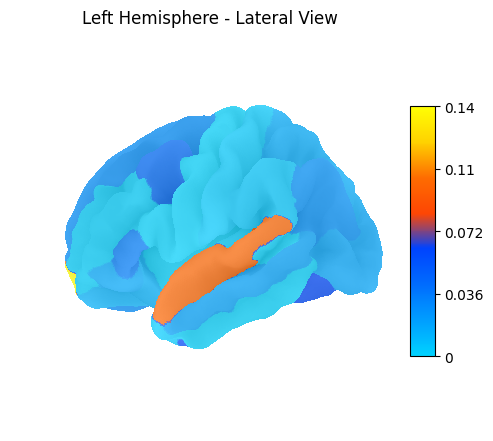

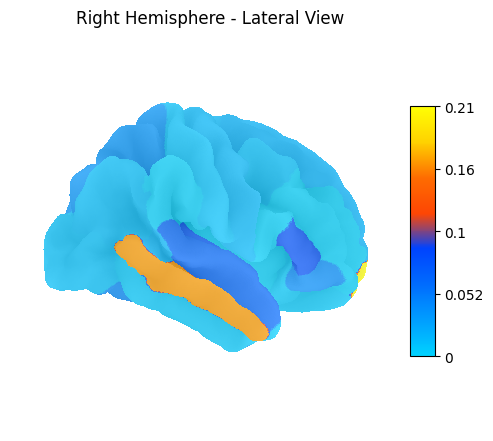

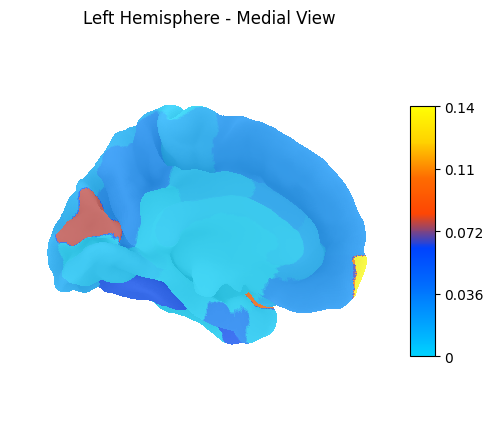

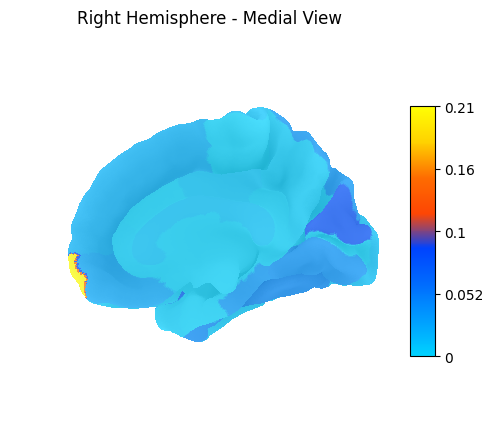

In [4]:
"""
Brain Mapping Data Processing Script
This script processes brain mapping data using the Cammoun 2012 atlas and FSAverage surface data.
It handles surface mesh loading, label mapping, scale calculations, and visualization.
"""

# Standard library imports
import numpy as np
import pandas as pd

# Third-party imports
import nibabel as nib
from nilearn import image
from nilearn.plotting import plot_surf_roi, plot_surf_stat_map, show
from nilearn.surface import load_surf_data, load_surf_mesh
from netneurotools import datasets
from netneurotools.datasets import fetch_cammoun2012, fetch_fsaverage

def load_surface_data():
    """
    Load surface data from Cammoun 2012 atlas and FSAverage.
    
    Returns:
        tuple: Left and right hemisphere annotation and mesh data
    """
    # Load Cammoun atlas data
    cammoun = fetch_cammoun2012('fsaverage')
    labelpath = cammoun['scale033']
    
    # Load hemisphere annotations
    lh_annot = load_surf_data(labelpath.lh)
    rh_annot = load_surf_data(labelpath.rh)
    
    # Load FSAverage surface data
    fsaverage = fetch_fsaverage('fsaverage')
    # mni = fetch_fsaverage()

    lh_mesh = load_surf_mesh(fsaverage.pial.lh)
    rh_mesh = load_surf_mesh(fsaverage.pial.rh)
    # print(lh_mesh.shape,rh_mesh.shape)
    lh_sulc = load_surf_mesh(fsaverage.orig.lh)
    rh_sulc = load_surf_mesh(fsaverage.orig.rh)
    
    return lh_annot, rh_annot, lh_mesh, rh_mesh, lh_sulc, rh_sulc

def process_cammoun_labels():
    """
    Process Cammoun atlas labels and create hemisphere-specific labels.
    
    Returns:
        list: Combined hemisphere and region labels
    """
    cammoun = fetch_cammoun2012()
    cammoun_info = pd.read_csv(cammoun['info'])
    cammoun_info = cammoun_info[cammoun_info['scale'] == 'scale033']
    
    # Combine hemisphere and label information
    labels = cammoun_info['label'].values
    hemispheres = cammoun_info['hemisphere'].values
    return [f'{hemi}_{label}' for hemi, label in zip(hemispheres, labels)]

def calculate_scale_permutation(cammoun_labels, sc_labels, diffusion_scales):
    """
    Calculate permutation mapping between structural connectivity labels and Cammoun labels.
    
    Args:
        cammoun_labels (array): Labels from Cammoun atlas
        sc_labels (array): Structural connectivity labels
        diffusion_scales (array): Diffusion scale values
    
    Returns:
        tuple: Permutation indices and scales for right and left hemispheres
    """
    # Find permutation indices
    perm = []
    for label in cammoun_labels:
        idx = np.where(sc_labels == label)[0]
        perm.append(idx[0] if len(idx) > 0 else -1)
    
    # Calculate scales for each hemisphere
    cammoun_scales = diffusion_scales[perm]
    cammoun_scales_rh = cammoun_scales[:34]
    cammoun_scales_lh = cammoun_scales[41:75]
    
    return perm, cammoun_scales_rh, cammoun_scales_lh

def map_scales_to_surface(annot, scales):
    """
    Map diffusion scales to surface vertices based on annotation labels.
    
    Args:
        annot (array): Surface annotation data
        scales (array): Scale values for each region
        
    Returns:
        array: Scale values mapped to each vertex
    """
    surface_scales = np.zeros_like(annot, dtype=float)
    
    # Map each scale value to its corresponding region
    for i, scale in enumerate(scales, 1):  # Starting from 1 as 0 is typically background
        surface_scales[annot == i] = scale
        
    return surface_scales

def plot_brain_scales(lh_mesh, rh_mesh, lh_annot, rh_annot, scales_lh, scales_rh, lh_sulc, rh_sulc):
    """
    Plot diffusion scales on brain surface for both hemispheres.
    
    Args:
        lh_mesh (tuple): Left hemisphere mesh data
        rh_mesh (tuple): Right hemisphere mesh data
        lh_annot (array): Left hemisphere annotations
        rh_annot (array): Right hemisphere annotations
        scales_lh (array): Left hemisphere scale values
        scales_rh (array): Right hemisphere scale values
    """
    import matplotlib
    from matplotlib import colors as mcolors, pyplot as plt



    matplotlib.colormaps.register(
        mcolors.LinearSegmentedColormap.from_list(
            'caret_blueorange', [
                '#00d2ff', '#009eff', '#006cfe', '#0043fe',
                '#fd4604', '#fe6b01', '#ffd100', '#ffff04'
                ]),
        name="caret_blueorange"
    )
    # Map scales to surface vertices
    lh_surface_scales = map_scales_to_surface(lh_annot, scales_lh)
    rh_surface_scales = map_scales_to_surface(rh_annot, scales_rh)
    
    # Create figure with multiple views
    views = ['lateral', 'medial']
    hemis = ['left', 'right']
    
    from nibabel import freesurfer
    lhsulc = freesurfer.io.read_morph_data('../data/lh.sulc')
    rhsulc = freesurfer.io.read_morph_data('../data/rh.sulc')
    cmap = 'caret_blueorange'
    # Plot each view
    for view in views:
        # Left hemisphere
        plot_surf_stat_map(
            lh_mesh, 
            lh_surface_scales,
            bg_map=lhsulc,
            hemi='left',
            view=view,
            colorbar=True,
            title=f'Left Hemisphere - {view.capitalize()} View',
            threshold=None,
            bg_on_data=True,
            cmap='caret_blueorange'
        )

        # save
        plt.savefig(f'../figure/rebuttal/diffusion_scales_lh_{view}_{cmap}.pdf',dpi=300)
        # Right hemisphere
        plot_surf_stat_map(
            rh_mesh, 
            rh_surface_scales,
            hemi='right',
            view=view,
            colorbar=True,
            title=f'Right Hemisphere - {view.capitalize()} View',
            bg_map=rhsulc,
            bg_on_data=True,
            threshold=None,
            cmap='caret_blueorange'
        )
        # save
        plt.savefig(f'../figure/rebuttal/diffusion_scales_rh_{view}_{cmap}.pdf',dpi=300)
    
    show()

def main():
    """Main execution function"""
    # Load surface data
    lh_annot, rh_annot, lh_mesh, rh_mesh, lh_sulc, rh_sulc = load_surface_data()
    
    # Process labels
    cammoun_labels = process_cammoun_labels()
    
    # Save original labels
    np.savetxt('../data/cammoun_labels_orig.txt', cammoun_labels, fmt='%s')
    
    # Load necessary data
    sc_labels = np.loadtxt('../data/sc_labels.txt', dtype=str)
    cammoun_labels = np.loadtxt('../data/cammoun_labels.txt', dtype=str)
    diffusion_scales = np.loadtxt('../data/scales.txt', dtype=float)
    
    # Calculate permutation and scales
    perm, scales_rh, scales_lh = calculate_scale_permutation(
        cammoun_labels, 
        sc_labels, 
        diffusion_scales
    )
    
    # Plot the scales on the brain surface
    plot_brain_scales(lh_mesh, rh_mesh, lh_annot, rh_annot, scales_lh, scales_rh, lh_sulc, rh_sulc)

if __name__ == "__main__":
    main()

(10242,)

In [17]:
# import matplotlib.pyplot as plt
# from nilearn import plotting

# # Load the atlas data
# cammoun = fetch_cammoun2012('fsaverage')
# surface_data = cammoun['scale060']
# surface_data

In [16]:

# # Visualize the left and right hemisphere surfaces
# plotting.plot_surf(surface_data.lh, surface_data.rh, hemi='split', view='lateral', background='white', cmap='tab20')
# plt.show()

In [2]:
import pandas as pd
from netneurotools.datasets import fetch_cammoun2012
cammoun = fetch_cammoun2012()
cammoun_info = pd.read_csv(cammoun['info'])
cammoun_info = cammoun_info[cammoun_info['scale'] == 'scale033']
cammoun_info

,id,label,hemisphere,structure,scale,yeo_7,von_economo
0,1,lateralorbitofrontal,R,cortex,scale033,limbic,primary/secondary sensory
1,2,parsorbitalis,R,cortex,scale033,default mode,primary/secondary sensory
2,3,frontalpole,R,cortex,scale033,limbic,association
3,4,medialorbitofrontal,R,cortex,scale033,limbic,primary/secondary sensory
4,5,parstriangularis,R,cortex,scale033,ventral attention,association
...,...,...,...,...,...,...,...
78,79,pallidum,L,subcortex,scale033,subcortex,subcortex
79,80,accumbensarea,L,subcortex,scale033,subcortex,subcortex
80,81,hippocampus,L,subcortex,scale033,subcortex,subcortex
81,82,amygdala,L,subcortex,scale033,subcortex,subcortex


In [8]:
import numpy as np
np.unique(cammoun_info['yeo_7'],return_counts=True)
# cammoun_info['yeo_7']

(array(['default mode', 'dorsal attention', 'frontoparietal', 'limbic',
        'somatomotor', 'subcortex', 'ventral attention', 'visual'],
       dtype=object),
 array([18,  2,  3, 12, 11, 15, 11, 11]))

Processing default mode network...
Processing dorsal attention network...
Processing frontoparietal network...
Processing limbic network...
Processing somatomotor network...
Processing ventral attention network...


/home/chirag/nas/Node Specific Assymetric Diffusion/nilearn/nilearn/plotting/surf_plotting.py:639: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figure = plt.figure(figsize=figsize)


Processing visual network...


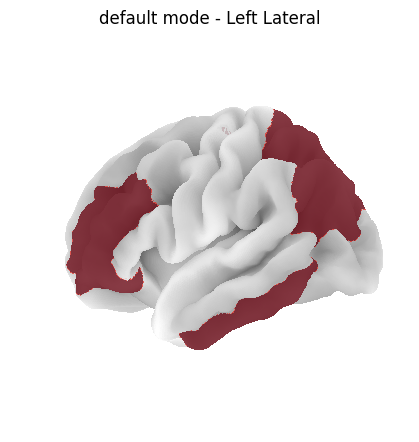

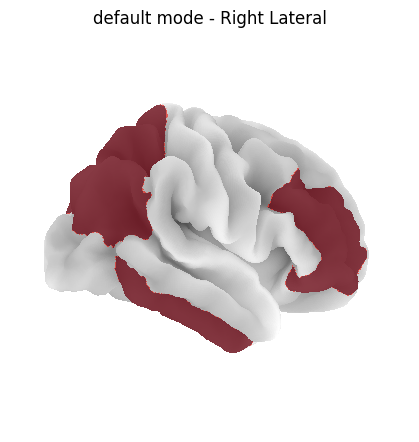

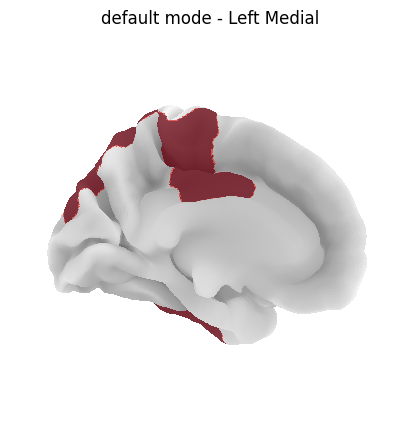

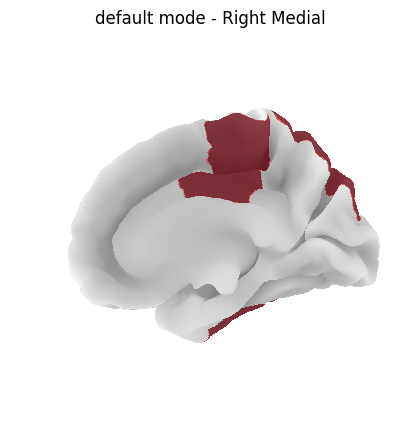

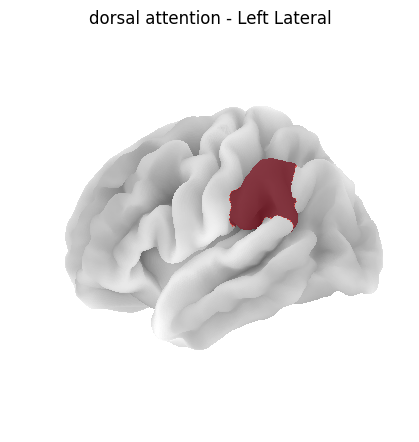

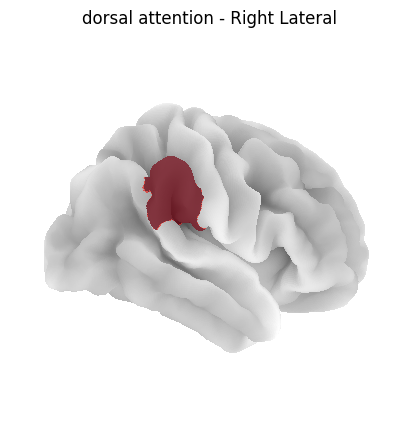

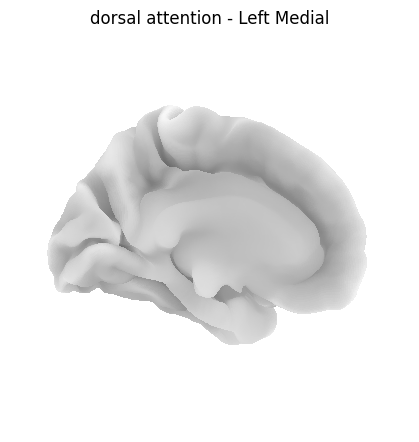

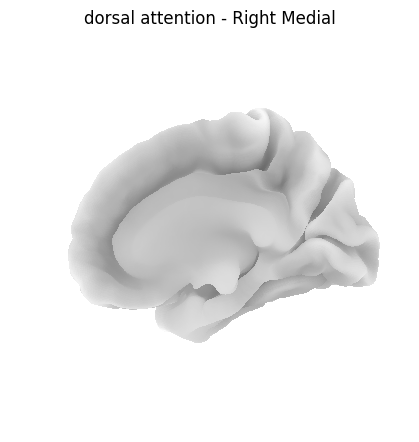

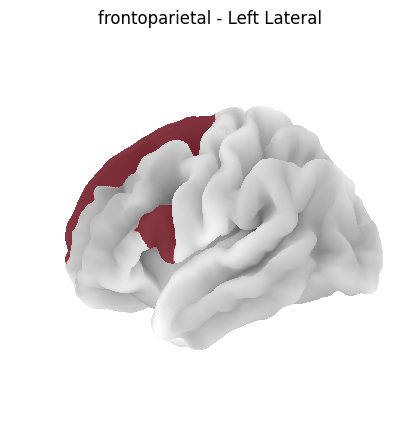

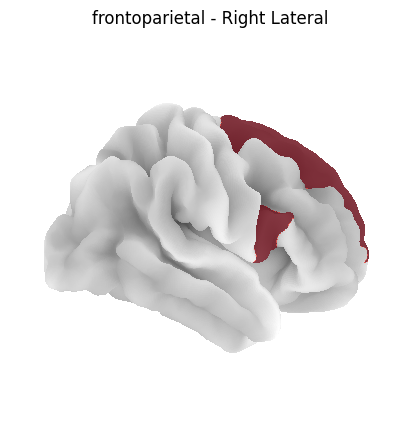

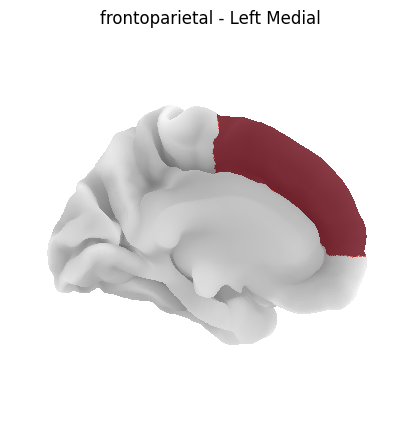

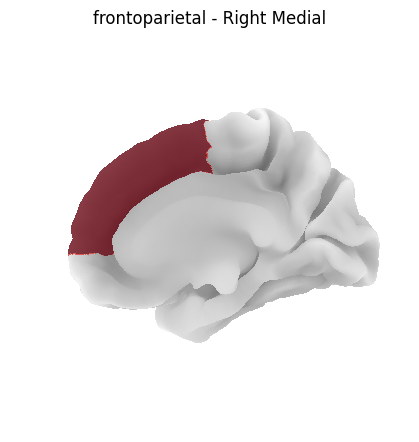

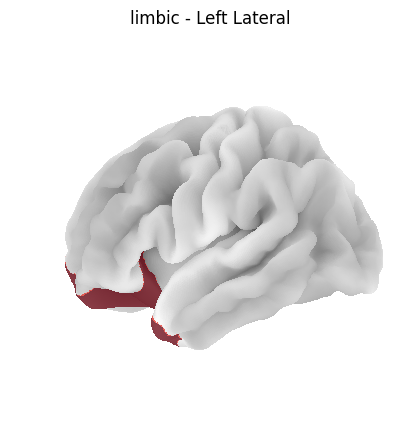

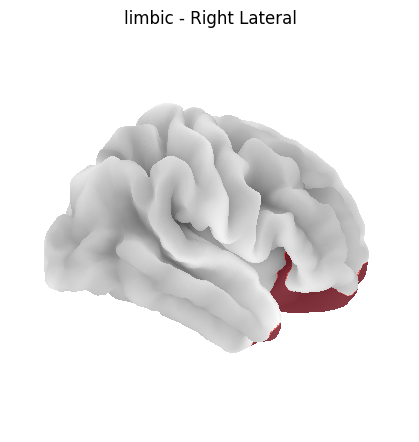

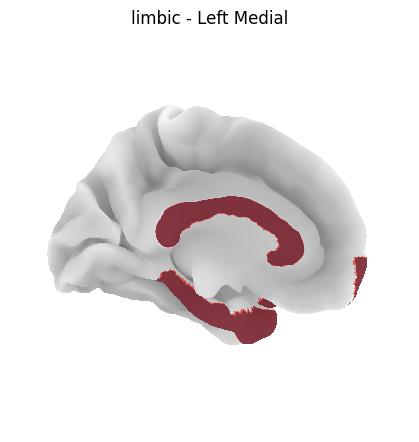

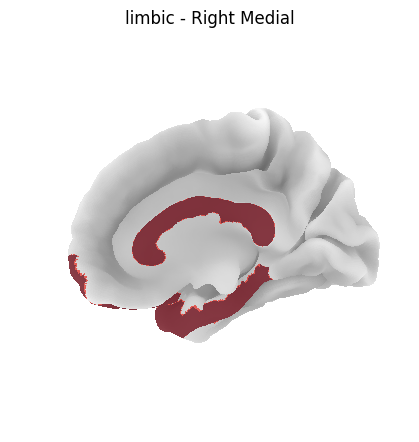

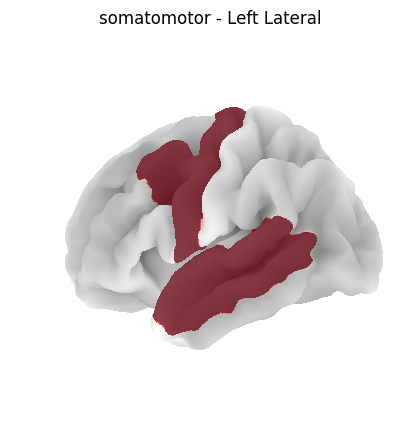

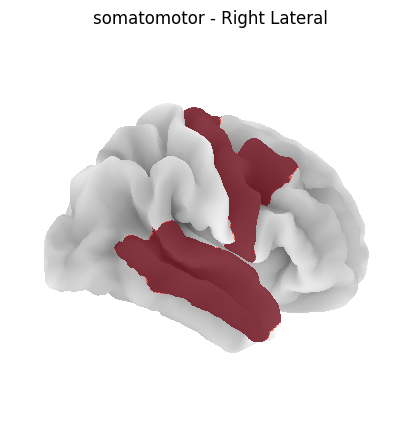

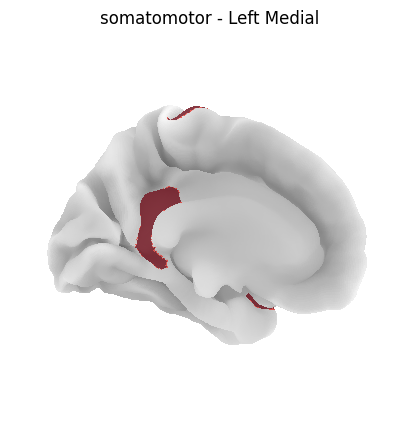

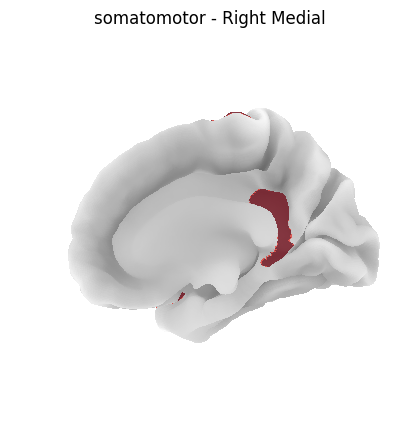

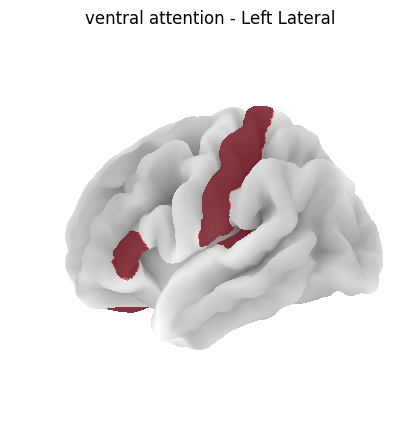

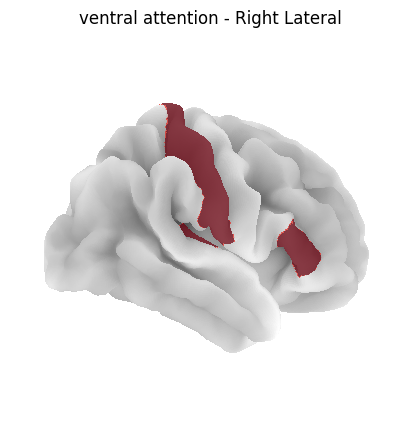

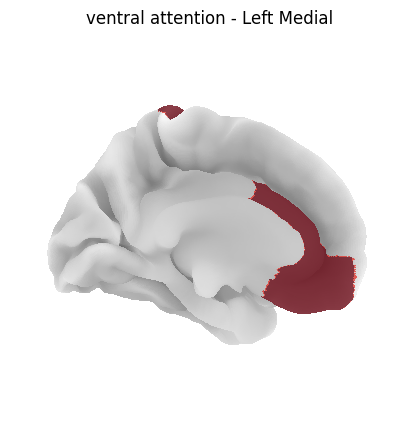

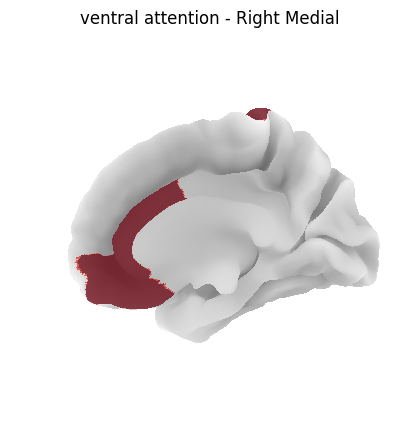

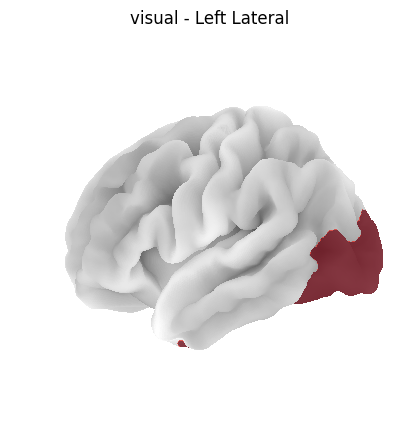

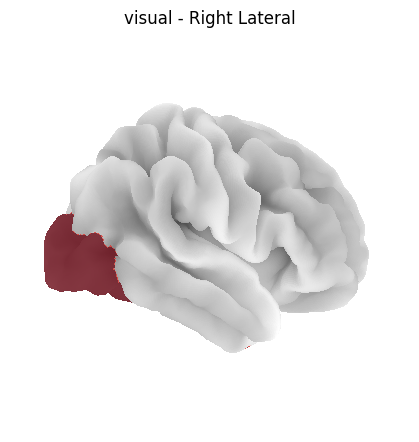

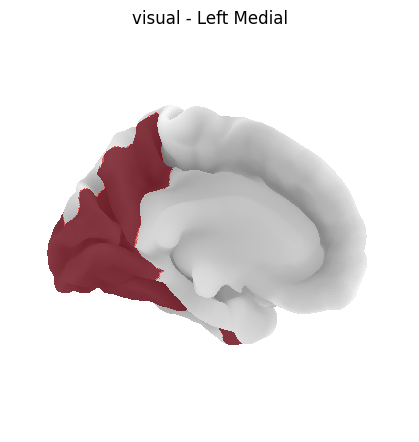

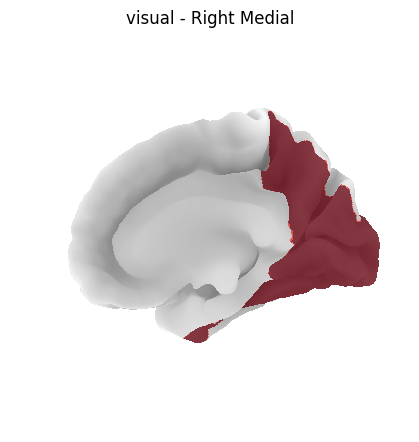

In [10]:
"""
Brain Network Visualization Script
Plots separate visualizations for each of the 7 Yeo networks using Cammoun atlas data
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.plotting import plot_surf_stat_map, show
from nilearn.surface import load_surf_data, load_surf_mesh
from netneurotools.datasets import fetch_cammoun2012, fetch_fsaverage
from nibabel import freesurfer

def load_surface_data():
    """Load surface and annotation data"""
    cammoun = fetch_cammoun2012('fsaverage')
    fsaverage = fetch_fsaverage('fsaverage')
    
    # Load annotations and meshes
    lh_annot = load_surf_data(cammoun['scale033'].lh)
    rh_annot = load_surf_data(cammoun['scale033'].rh)
    lh_mesh = load_surf_mesh(fsaverage.pial.lh)
    rh_mesh = load_surf_mesh(fsaverage.pial.rh)
    
    # Load sulc data
    lh_sulc = freesurfer.io.read_morph_data('../data/lh.sulc')
    rh_sulc = freesurfer.io.read_morph_data('../data/rh.sulc')
    
    return lh_annot, rh_annot, lh_mesh, rh_mesh, lh_sulc, rh_sulc

def get_network_data():
    """Get Cammoun atlas info with Yeo network assignments"""
    cammoun = fetch_cammoun2012()
    cammoun_info = pd.read_csv(cammoun['info'])
    return cammoun_info[cammoun_info['scale'] == 'scale033']

def create_network_map(annot, network_indices, value=1.0):
    """Create binary map for a specific network"""
    network_map = np.zeros_like(annot, dtype=float)
    for idx in network_indices:
        network_map[annot == (idx + 1)] = value
    return network_map

def plot_network(mesh, data, sulc, hemi, view, network_name, output_dir='../figure/rebuttal/yeo7/'):
    """Plot single network view"""
    plot_surf_stat_map(
        mesh,
        data,
        hemi=hemi,
        view=view,
        bg_map=sulc,
        bg_on_data=True,
        threshold=0.5,  # Show only network regions
        colorbar=False,
        alpha=0.8,
        cmap='Reds',  # Single color for network
        title=f'{network_name} - {hemi.capitalize()} {view.capitalize()}'
    )
    plt.savefig(
        f'{output_dir}{network_name.replace(" ", "_")}_{hemi}_{view}.pdf',
        dpi=300,
        bbox_inches='tight'
    )

def visualize_yeo_networks():
    """Main function to visualize all Yeo networks"""
    # Load all required data
    lh_annot, rh_annot, lh_mesh, rh_mesh, lh_sulc, rh_sulc = load_surface_data()
    cammoun_info = get_network_data()
    
    # Define Yeo networks
    yeo_networks = [
        'default mode', 'dorsal attention', 'frontoparietal',
        'limbic', 'somatomotor', 'ventral attention', 'visual'
    ]
    
    views = ['lateral', 'medial']
    hemis = ['left', 'right']
    
    # Process each network
    for network in yeo_networks:
        print(f"Processing {network} network...")
        
        # Get regions belonging to current network
        network_regions = cammoun_info[cammoun_info['yeo_7'] == network].index.values
        
        # Create left and right hemisphere maps
        lh_network = create_network_map(lh_annot, network_regions)
        rh_network = create_network_map(rh_annot, network_regions)
        
        # Plot all views for current network
        for view in views:
            # Left hemisphere
            plot_network(
                lh_mesh, lh_network, lh_sulc,
                'left', view, network
            )
            
            # Right hemisphere
            plot_network(
                rh_mesh, rh_network, rh_sulc,
                'right', view, network
            )
    
    show()

if __name__ == "__main__":
    visualize_yeo_networks()

In [20]:
cammoun_info['yeo_7'].unique()

array(['limbic', 'default mode', 'ventral attention', 'frontoparietal',
       'somatomotor', 'dorsal attention', 'visual', 'subcortex'],
      dtype=object)

In [18]:
"""
Brain Network Diffusion Scale Visualization
Plots diffusion scales specifically for regions within a selected Yeo network
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.plotting import plot_surf_stat_map, show
from nilearn.surface import load_surf_data, load_surf_mesh
from netneurotools.datasets import fetch_cammoun2012, fetch_fsaverage
from nibabel import freesurfer
import matplotlib
import matplotlib.colors as mcolors
# # Register custom colormap
# matplotlib.colormaps.register(
#     mcolors.LinearSegmentedColormap.from_list(
#         'caret_blueorange', [
#             '#00d2ff', '#009eff', '#006cfe', '#0043fe',
#             '#fd4604', '#fe6b01', '#ffd100', '#ffff04'
#         ]),
#     name="caret_blueorange"
# )
def load_surface_data():
    """Load surface and annotation data"""
    cammoun = fetch_cammoun2012('fsaverage')
    fsaverage = fetch_fsaverage('fsaverage')
    
    # Load annotations and meshes
    lh_annot = load_surf_data(cammoun['scale033'].lh)
    rh_annot = load_surf_data(cammoun['scale033'].rh)
    lh_mesh = load_surf_mesh(fsaverage.pial.lh)
    rh_mesh = load_surf_mesh(fsaverage.pial.rh)
    
    # Load sulc data
    lh_sulc = freesurfer.io.read_morph_data('../data/lh.sulc')
    rh_sulc = freesurfer.io.read_morph_data('../data/rh.sulc')
    
    return lh_annot, rh_annot, lh_mesh, rh_mesh, lh_sulc, rh_sulc

def get_network_data():
    """Get Cammoun atlas info with Yeo network assignments"""
    cammoun = fetch_cammoun2012()
    cammoun_info = pd.read_csv(cammoun['info'])
    return cammoun_info[cammoun_info['scale'] == 'scale033']

def map_network_scales(annot, scales, network_indices):
    """
    Map diffusion scales to surface vertices for specific network regions.
    
    Args:
        annot: Surface annotation data
        scales: Scale values for each region
        network_indices: Indices of regions in the network
    """
    surface_scales = np.zeros_like(annot, dtype=float)
    surface_scales[:] = np.nan  # Set non-network regions to NaN
    
    for i, scale in enumerate(scales, 1):
        if i-1 in network_indices:  # -1 because indices start at 0
            surface_scales[annot == i] = scale
            
    return surface_scales

def plot_network_scales(network_name='default mode'):
    """Plot diffusion scales for a specific network"""
    # Load data
    lh_annot, rh_annot, lh_mesh, rh_mesh, lh_sulc, rh_sulc = load_surface_data()
    cammoun_info = get_network_data()
    
    # Load diffusion scales
    sc_labels = np.loadtxt('../data/sc_labels.txt', dtype=str)
    cammoun_labels = np.loadtxt('../data/cammoun_labels.txt', dtype=str)
    diffusion_scales = np.loadtxt('../data/scales.txt', dtype=float)
    
    # Get network regions
    network_regions = cammoun_info[cammoun_info['yeo_7'] == network_name].index.values
    
    # Calculate permutation for scales
    perm = []
    for label in cammoun_labels:
        idx = np.where(sc_labels == label)[0]
        perm.append(idx[0] if len(idx) > 0 else -1)
    
    # Get scales for each hemisphere
    cammoun_scales = diffusion_scales[perm]
    scales_rh = cammoun_scales[:34]
    scales_lh = cammoun_scales[41:75]
    
    # Map scales for network regions
    lh_network_scales = map_network_scales(lh_annot, scales_lh, 
                                         network_regions[network_regions < 34])
    rh_network_scales = map_network_scales(rh_annot, scales_rh, 
                                         network_regions[network_regions >= 41] - 41)
    

    
    # Plot views
    views = ['lateral', 'medial']
    for view in views:
        # Left hemisphere
        plot_surf_stat_map(
            lh_mesh,
            lh_network_scales,
            bg_map=lh_sulc,
            hemi='left',
            view=view,
            colorbar=True,
            bg_on_data=True,
            threshold=None,
            cmap='caret_blueorange',
            title=f'{network_name.capitalize()} Network - Left {view.capitalize()}'
        )
        plt.savefig(f'../figure/rebuttal/network_scales/{network_name.replace(" ", "_")}_left_{view}.png',
                    dpi=300, bbox_inches='tight')
        
        # Right hemisphere
        plot_surf_stat_map(
            rh_mesh,
            rh_network_scales,
            bg_map=rh_sulc,
            hemi='right',
            view=view,
            colorbar=True,
            bg_on_data=True,
            threshold=None,
            cmap='caret_blueorange',
            title=f'{network_name.capitalize()} Network - Right {view.capitalize()}'
        )
        plt.savefig(f'../figure/rebuttal/network_scales/{network_name.replace(" ", "_")}_right_{view}.png',
                    dpi=300, bbox_inches='tight')
    
    show()

if __name__ == "__main__":
    # Specify the network to visualize
    network_name = 'default mode'  # Change this to visualize different networks
    plot_network_scales(network_name)

KeyboardInterrupt: 